# Telecom Churn Rate

The Orange Telecom dataset contains customer-level records capturing demographics, service subscriptions, usage patterns, billing and payment information, and a churn indicator that marks whether a customer left the service. It is designed for analyzing customer behavior and understanding the factors that drive churn.

The data was taken from the following [URL](https://www.kaggle.com/datasets/mnassrib/telecom-churn-datasets/data)


In [1]:
import graphviz

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import accuracy_score

## Data Understanding

In [2]:
churn_df = pd.read_csv("../data/telecom_clients/churn-bigml-80.csv")
churn_df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [3]:
def describe(df):

    unique = []
    for col in df.columns:
        unique.append(df[col].unique())
    unique_series = pd.Series(unique, index=df.columns)
    return pd.concat(
        [
            df.dtypes,
            df.isna().sum(),
            round(df.isna().sum() / len(df) * 100, 1),
            df.nunique(),
            unique_series,
        ],
        axis=1,
        keys=["dtype", "missing", "%null", "nunique", "unique"],
    )


describe(churn_df)

,dtype,missing,%null,nunique,unique
State,str,0,0.0,51,"[KS, OH, NJ, OK, AL, MA, MO, WV, RI, IA, MT, I..."
Account length,int64,0,0.0,205,"[128, 107, 137, 84, 75, 118, 121, 147, 141, 74..."
Area code,int64,0,0.0,3,"[415, 408, 510]"
International plan,str,0,0.0,2,"[No, Yes]"
Voice mail plan,str,0,0.0,2,"[Yes, No]"
Number vmail messages,int64,0,0.0,42,"[25, 26, 0, 24, 37, 27, 33, 39, 41, 28, 30, 34..."
Total day minutes,float64,0,0.0,1489,"[265.1, 161.6, 243.4, 299.4, 166.7, 223.4, 218..."
Total day calls,int64,0,0.0,115,"[110, 123, 114, 71, 113, 98, 88, 79, 84, 127, ..."
Total day charge,float64,0,0.0,1489,"[45.07, 27.47, 41.38, 50.9, 28.34, 37.98, 37.0..."
Total eve minutes,float64,0,0.0,1442,"[197.4, 195.5, 121.2, 61.9, 148.3, 220.6, 348...."


## Exploración y Preprocesamiento

In [4]:
churn_df["Churn"].value_counts(normalize=True)

Churn
False    0.854464
True     0.145536
Name: proportion, dtype: float64

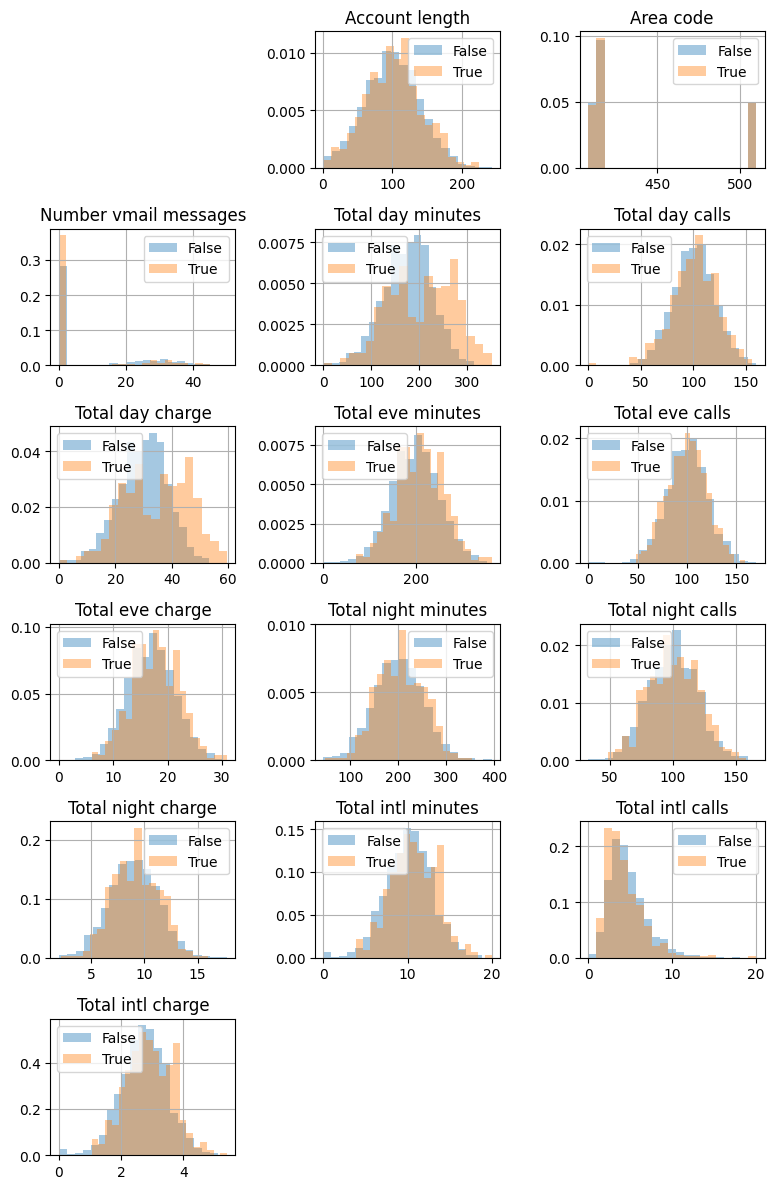

In [5]:
numericas_cols = churn_df.select_dtypes("number").columns

fig, subplot = plt.subplots(nrows=6, ncols=3, figsize=(8, 12))
subplot = subplot.flatten()

for i, column in enumerate(numericas_cols[:-1]):
    churn_df.groupby("Churn")[column].hist(
        alpha=0.4, bins=20, ax=subplot[i + 1], density=True
    )
    subplot[i + 1].set_title(column)
    subplot[i + 1].legend(churn_df["Churn"].unique())

plt.tight_layout()
subplot[0].set_visible(False)
subplot[-1].set_visible(False)
subplot[-2].set_visible(False)
plt.show()

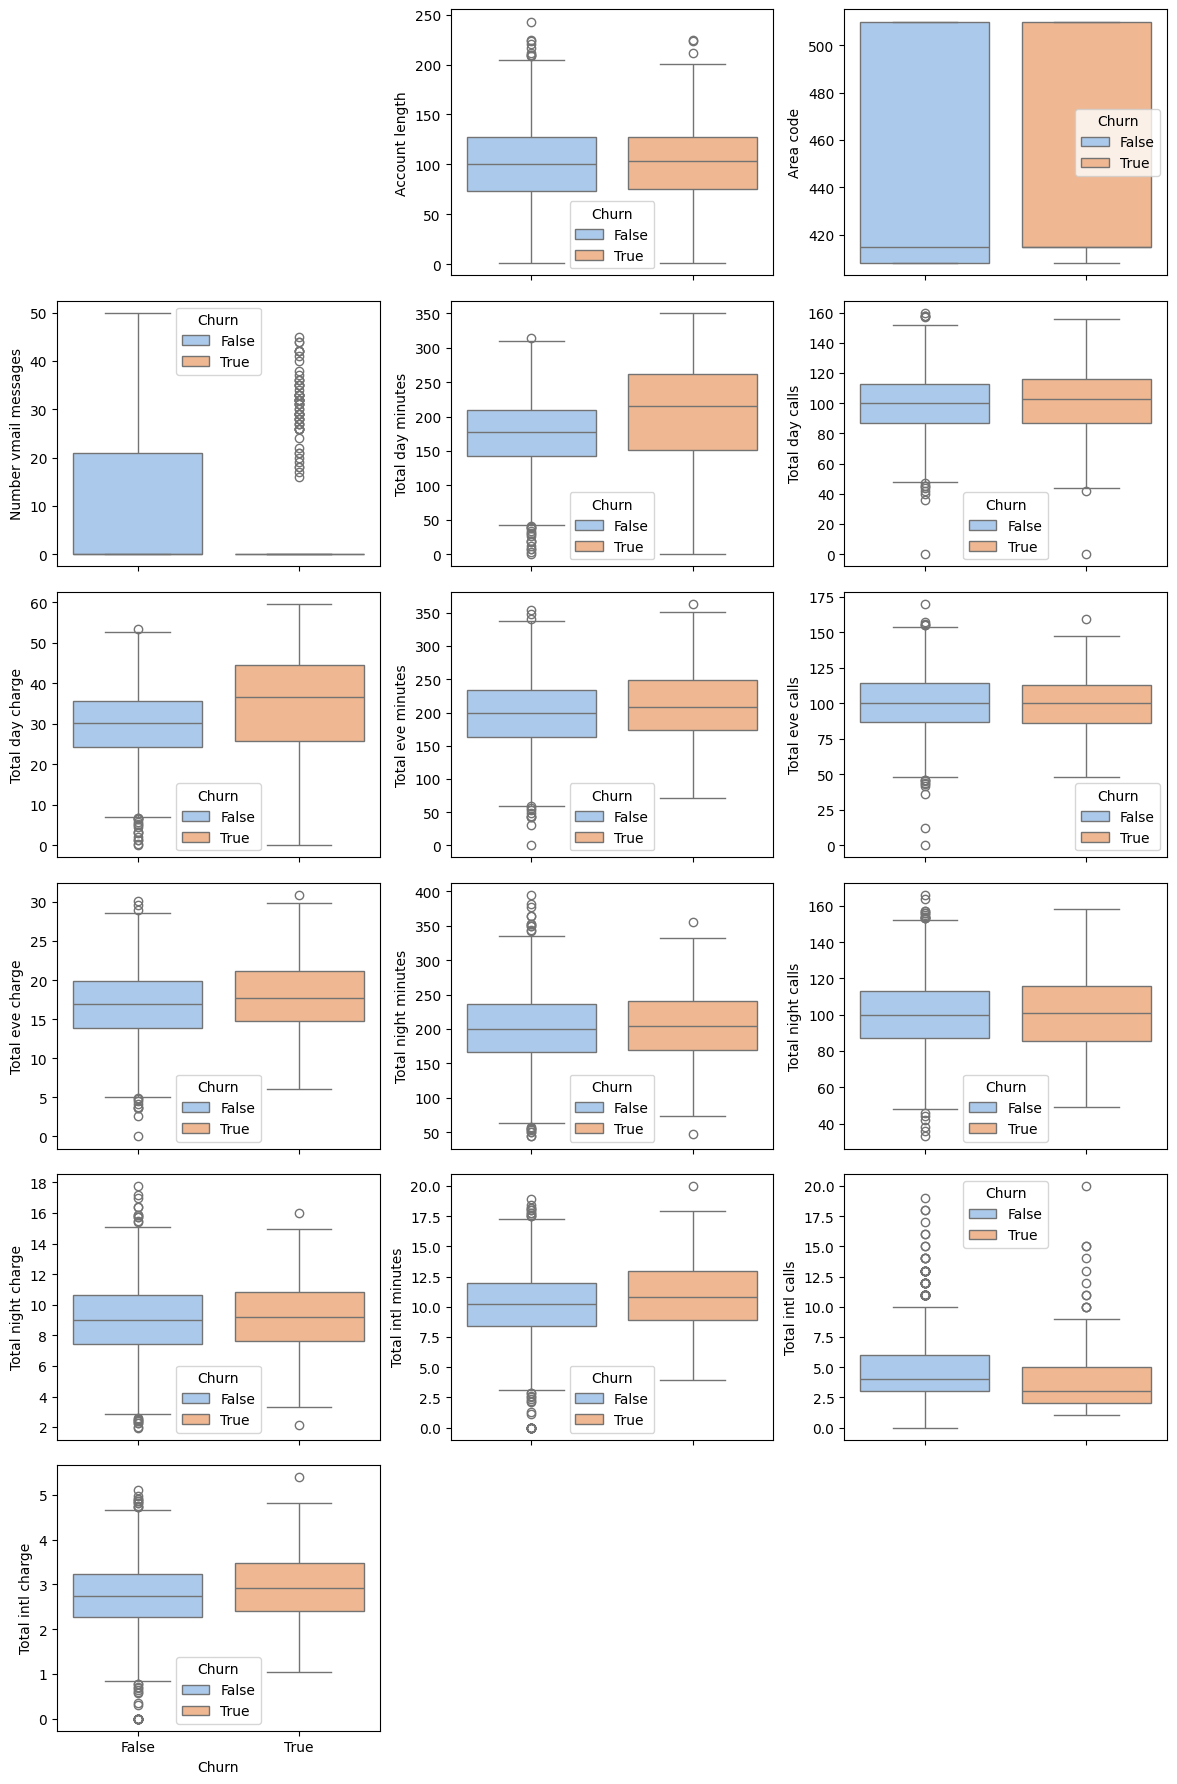

In [6]:
numericas_cols = churn_df.select_dtypes("number").columns
fig, subplot = plt.subplots(nrows=6, ncols=3, figsize=(12, 18), sharex=True)
subplot = subplot.flatten()

for i, col in enumerate(numericas_cols[:-1]):
    sns.boxplot(
        y=col,
        x="Churn",
        hue="Churn",
        data=churn_df,
        orient="v",
        palette="pastel",
        ax=subplot[i + 1,],
    )

plt.tight_layout()
subplot[0].set_visible(False)
subplot[-1].set_visible(False)
subplot[-2].set_visible(False)
plt.show()

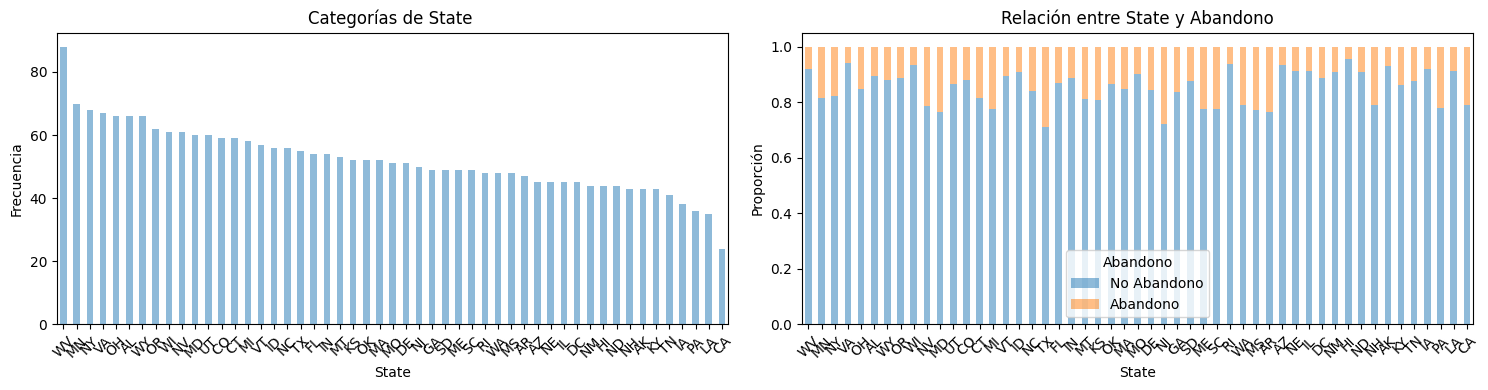

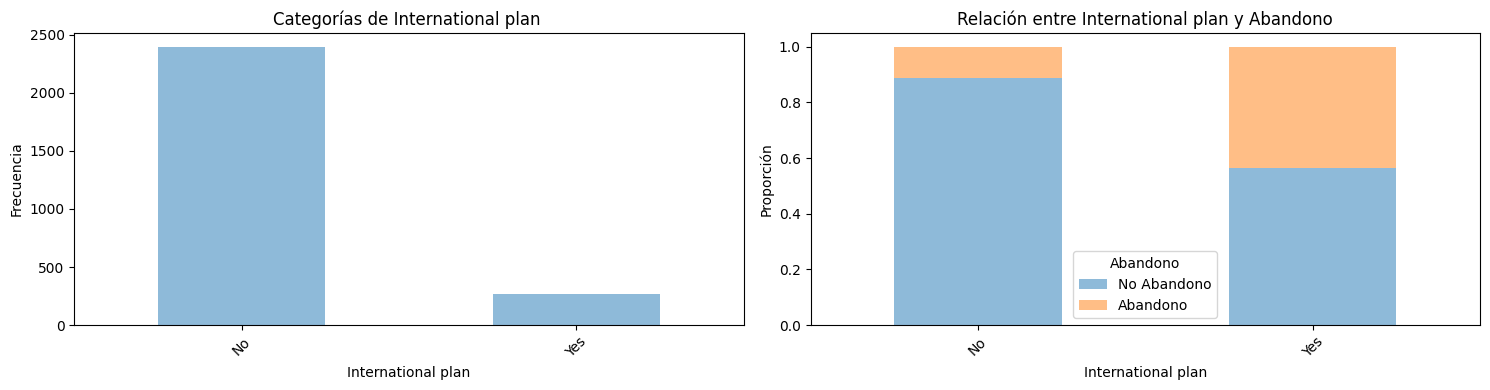

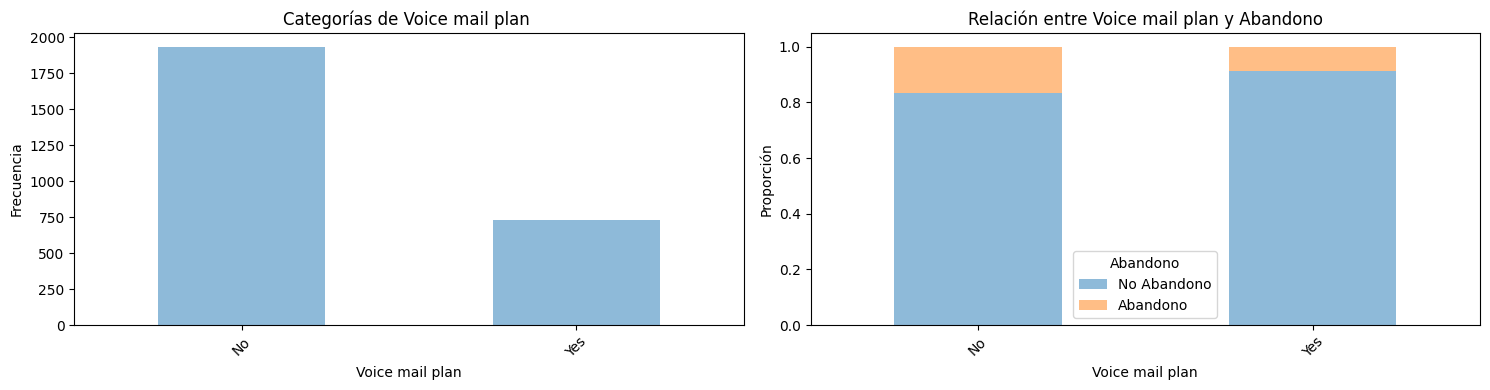

In [7]:
categoricas_cols = churn_df.select_dtypes(include=["object", "string"]).columns

for col in categoricas_cols:
    counts = churn_df[col].value_counts()
    order = counts.index.tolist()

    fig, axes = plt.subplots(
        1, 2, figsize=(15, 4)
    )  # Create a figure with 1 row and 2 columns

    # Gráfico de Frecuencia
    counts.plot(kind="bar", ax=axes[0], alpha=0.5)
    axes[0].set_title(f"Categorías de {col} ")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Frecuencia")
    axes[0].tick_params(axis="x", rotation=45)

    # Gráfico de Barras Apilada
    crosstab = pd.crosstab(churn_df[col], churn_df["Churn"], normalize="index")
    crosstab = crosstab.reindex(order, axis=0)

    crosstab.plot(kind="bar", stacked=True, ax=axes[1], alpha=0.5)
    axes[1].set_title(f"Relación entre {col} y Abandono")
    axes[1].set_xlabel(col)
    axes[1].set_ylabel("Proporción")
    axes[1].tick_params(axis="x", rotation=45)
    axes[1].legend(title="Abandono", labels=["No Abandono", "Abandono"])

    plt.tight_layout()
    plt.show()

# Ingenieria de Caracteristicas

In [8]:
encoder = OneHotEncoder(drop="if_binary", handle_unknown="ignore", sparse_output=False)
encoder.fit(churn_df[categoricas_cols]).set_output(transform="pandas")

,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",'if_binary'
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a :class:`scipy.sparse.csr_matrix`,i.e. a sparse matrix in ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",False
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide `.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'ignore'
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide `.",None
,"m

In [9]:
def preprocesar_datos(df_input, encoder, categoricas_cols) -> tuple:
    # Aplicar en encoder(OHE) que aprendió con el conjunto de entrenamiento
    df_cat_encoded = encoder.transform(df_input[categoricas_cols])

    # Remplazar las variables categoricas por las nuevas columnas creadas mediante OHE
    df_final = df_input.drop(columns=categoricas_cols)
    df_final = pd.concat([df_final, df_cat_encoded], axis=1)

    # Separar la etiqueta de las características
    y = df_final["Churn"]
    X = df_final.drop("Churn", axis=1)
    return X, y

In [10]:
X, y = preprocesar_datos(churn_df, encoder, categoricas_cols)

## Division en conjunto de entrenamiento y prueba

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=True, stratify=churn_df["Churn"], random_state=42
)

len(X_train), len(X_test), len(y_train), len(y_test)

(2132, 534, 2132, 534)

## Entrenamiento del Modelo

In [12]:
profundidad = None

# Entrenamiento del modelo.
clasificador = DecisionTreeClassifier(max_depth = profundidad,
                                      criterion="entropy",
                                      random_state=0)
clasificador.fit(X_train, y_train)
print("La profundida del árbol es: {}".format(clasificador.get_depth()))

La profundida del árbol es: 23


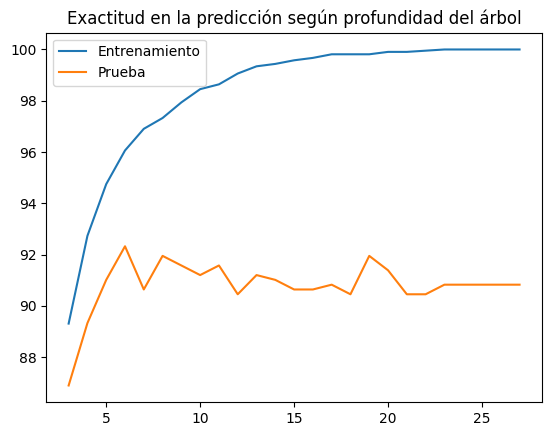

In [13]:
# Entrenamiento y prueba del modelo con distintos niveles de profunidad

clf = {}
y_pred_train = {}
y_pred_test = {}
exactitud_train = {}
exactitud_test = {}

for p in range(3, 28):
    # Entrenamiento del modelo
    clf[p] = DecisionTreeClassifier(
        max_depth=p, criterion="entropy", random_state=0
    ).fit(X_train, y_train)

    # Predicción y evaluación sobre el conjunto de entrenamiento
    y_pred_train[p] = clf[p].predict(X_train)
    exactitud_train[p] = accuracy_score(y_train, y_pred_train[p]) * 100

    # Predicción y evaluación sobre el conjunto de prueba
    y_pred_test[p] = clf[p].predict(X_test)
    exactitud_test[p] = accuracy_score(y_test, y_pred_test[p]) * 100

exactitud_df = pd.DataFrame(
    {"Entrenamiento": exactitud_train, "Prueba": exactitud_test}
)

exactitud_df.plot.line(title="Exactitud en la predicción según profundidad del árbol")
plt.show()

In [14]:
profundidad_optima = exactitud_df['Prueba'].idxmax()
profundidad_optima

np.int64(6)

In [15]:
model = clf[profundidad_optima]
model

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

## Evaluacion del Modelo

In [16]:
# Predicción y evaluación sobre el conjunto de entrenamiento.
y_pred_train = model.predict(X_train)
exactitud_train = accuracy_score(y_train, y_pred_train)*100
print("Exactitud conjunto de entrenamiento: {:4.2f}%".format(exactitud_train))

# Predicción y evaluación sobre el conjunto de prueba.
y_pred_test = model.predict(X_test)
exactitud_test = accuracy_score(y_test, y_pred_test)*100
print("Exactitud conjunto de prueba: {:4.2f}%".format(exactitud_test),'\n')

Exactitud conjunto de entrenamiento: 96.06%
Exactitud conjunto de prueba: 92.32% 



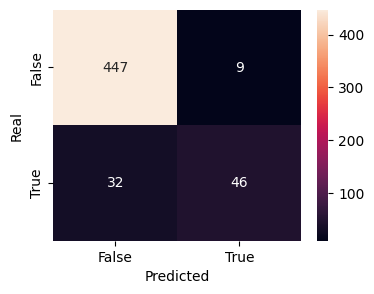

In [17]:
#Matriz de confusión
data = {'y_Real':y_test, 'y_Prediccion':model.predict(X_test)}

df = pd.DataFrame(data)
confusion_matrix = pd.crosstab(df['y_Real'], df['y_Prediccion'],
                               rownames=['Real'], colnames=['Predicted'])
fig, ax = plt.subplots(figsize=(4,3))
sns.heatmap(confusion_matrix, annot=True, fmt='g')
plt.show()

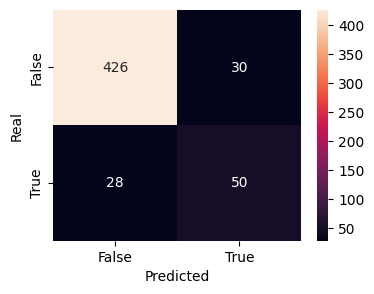

In [18]:
umbral = 0.2  # por arriba del cual se clasificaría como clase 1
prediccion_test = np.where(model.predict_proba(X_test)[:, 1] > umbral, True, False)
data = {"y_Real": y_test, "y_Prediccion": prediccion_test}

evaluacion_df = pd.DataFrame(data)
confusion_matrix = pd.crosstab(
    evaluacion_df["y_Real"],
    evaluacion_df["y_Prediccion"],
    rownames=["Real"],
    colnames=["Predicted"],
)
fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(confusion_matrix, annot=True, fmt="g")
plt.show()

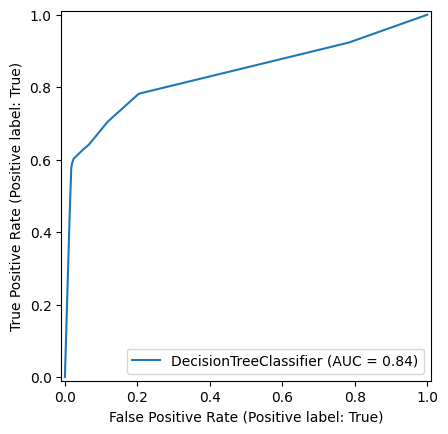

In [19]:
RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.show()

## Visualizar el arbol de decision

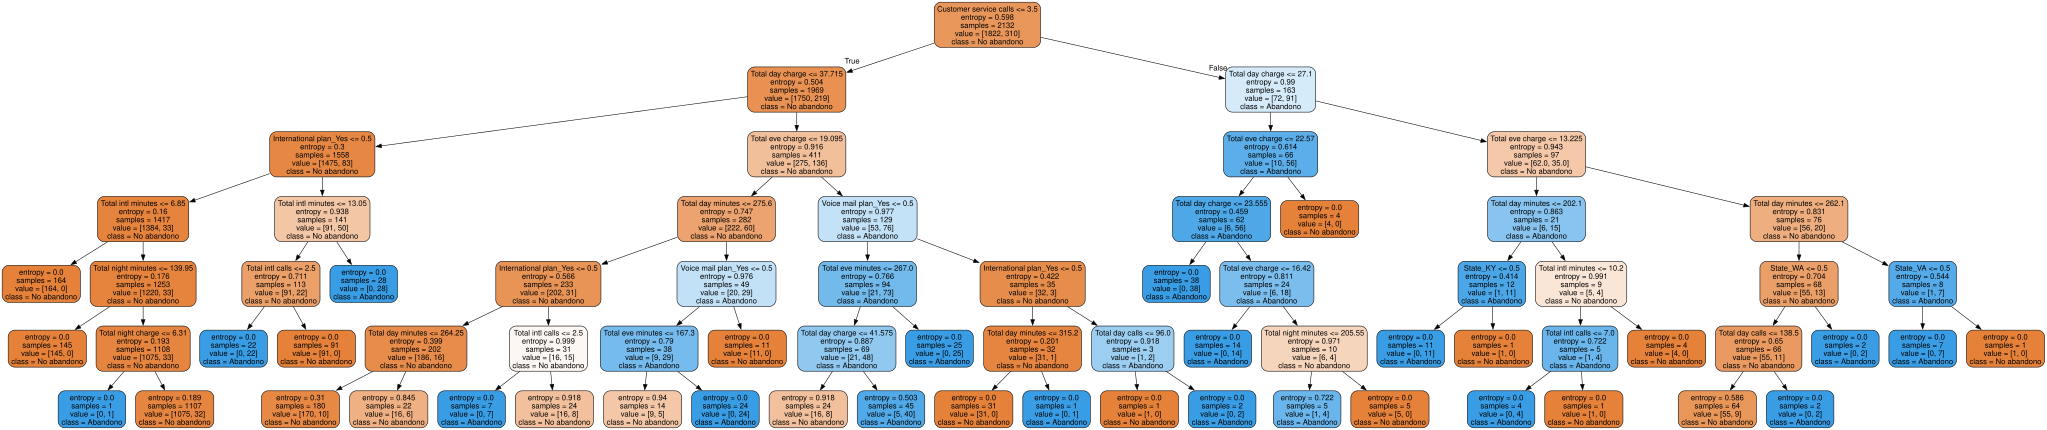

In [20]:
dot_data = export_graphviz(
    model,
    feature_names=X_train.columns,
    class_names=["No abandono", "Abandono"],
    max_depth=9,
    rounded=True,
    filled=True,
)

graph = graphviz.Source(dot_data, format="png")

graph

## Importancia de cada variable

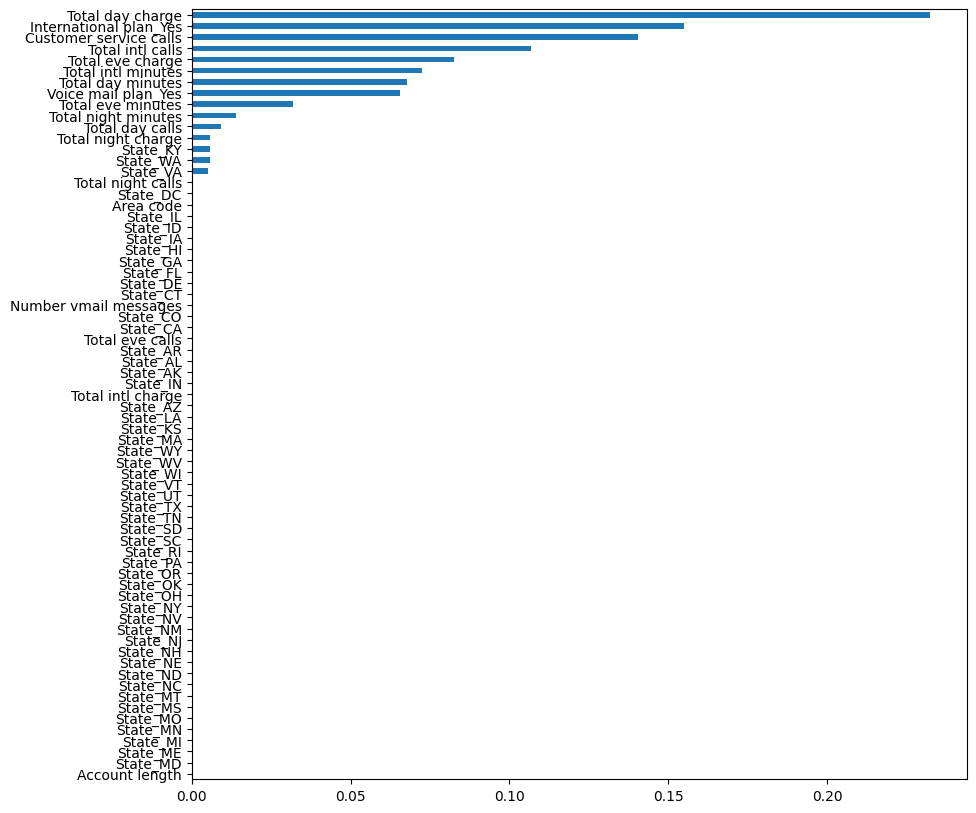

In [21]:
importancia = pd.Series(model.feature_importances_,
                    index=X_train.columns.values)

importancia.sort_values().plot(kind = 'barh',figsize=(10, 10))
plt.show()